In [1]:
import pandas as pd
import numpy as np
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

In [2]:
# verifica dati caricati
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [3]:
#dimensione del dataset
df.shape

(429435, 67)

In [5]:
# struttura dati e tipi di colonne
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [6]:
# seleziono solo i continenti
continenti = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania"]

df_continenti = df[df["location"].isin(continenti)]

# prendo l'ultimo valore disponibile per ogni continente
casi_totali = df_continenti.groupby("location")["total_cases"].max()

print("Casi totali per continente:")
print(casi_totali)


Casi totali per continente:
location
Africa            13145380.0
Asia             301499099.0
Europe           252916868.0
North America    124492666.0
Oceania           15003352.0
South America     68809418.0
Name: total_cases, dtype: float64


In [7]:
# totale mondiale
totale_mondo = df[df["location"] == "World"]["total_cases"].max()

percentuali = (casi_totali / totale_mondo) * 100

print("Percentuale rispetto al totale mondiale:")
print(percentuali)


Percentuale rispetto al totale mondiale:
location
Africa            1.694283
Asia             38.859648
Europe           32.597976
North America    16.045624
Oceania           1.933754
South America     8.868716
Name: total_cases, dtype: float64


In [12]:
df["date"] = pd.to_datetime(df["date"])

In [13]:
# seleziono solo Italia
italia = df[df["location"] == "Italy"]

# filtro solo anno 2022
italia_2022 = italia[italia["date"].dt.year == 2022]


In [15]:
# elimino le righe dove new cases è NaN
italia_2022 = italia_2022.dropna(subset=["new_cases"])


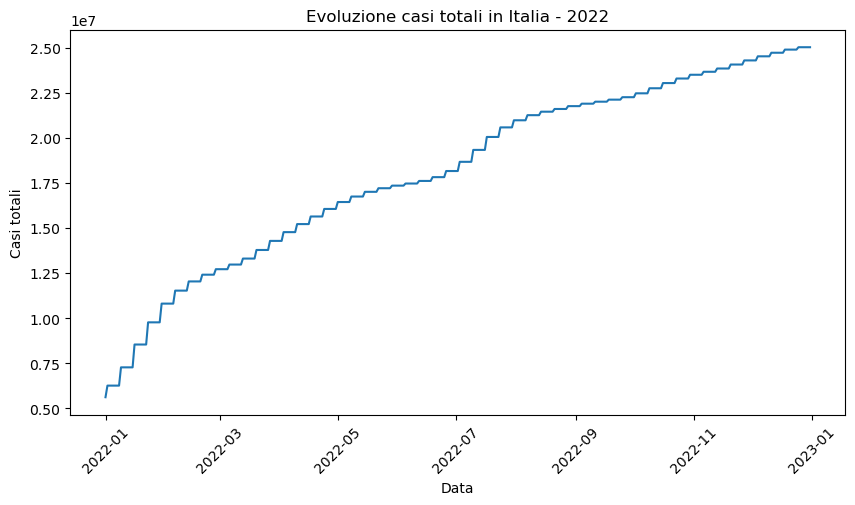

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(italia_2022["date"], italia_2022["total_cases"])

plt.title("Evoluzione casi totali in Italia - 2022")
plt.xlabel("Data")
plt.ylabel("Casi totali")
plt.xticks(rotation=45)

plt.show()

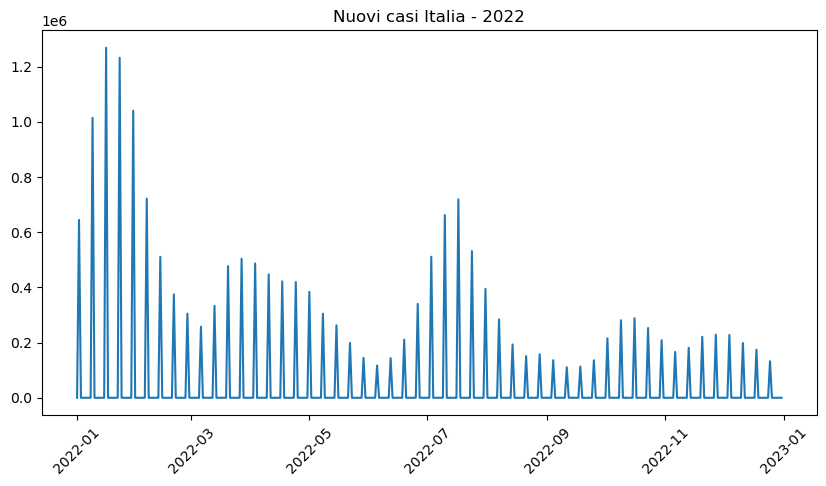

In [18]:
# seleziono Italia
italia = df[df["location"] == "Italy"]

# filtro anno 2022
italia_2022 = italia[italia["date"].dt.year == 2022]

# elimino i giorni senza misurazione dei nuovi casi
italia_2022 = italia_2022.dropna(subset=["new_cases"])

# grafico nuovi casi 2022
plt.figure(figsize=(10,5))
plt.plot(italia_2022["date"], italia_2022["new_cases"])
plt.title("Nuovi casi Italia - 2022")
plt.xticks(rotation=45)
plt.show()


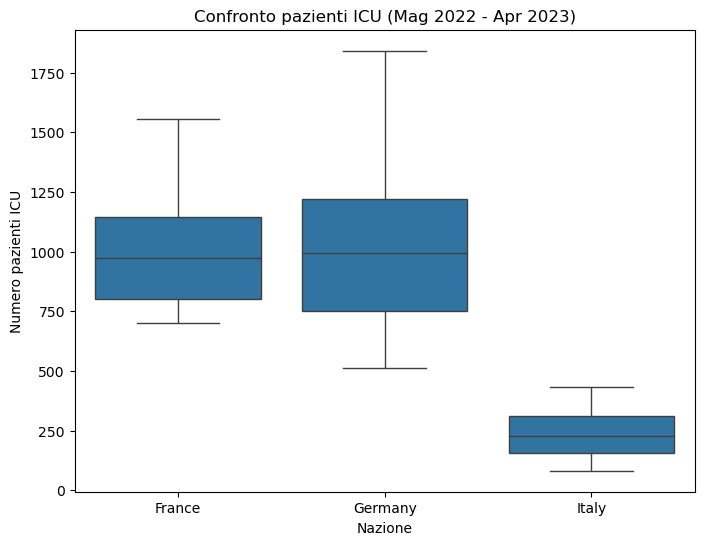

In [20]:

import seaborn as sns  
import matplotlib.pyplot as plt 

# nazioni da analizzare
nazioni = ["Italy", "Germany", "France"]

df_nazioni = df[df["location"].isin(nazioni)]

# filtro periodo
df_nazioni = df_nazioni[
    (df_nazioni["date"] >= "2022-05-01") &
    (df_nazioni["date"] <= "2023-04-30")
]

# elimino valori mancanti di pazienti icu
df_nazioni = df_nazioni.dropna(subset=["icu_patients"])

# boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x="location", y="icu_patients", data=df_nazioni)

plt.title("Confronto pazienti ICU (Mag 2022 - Apr 2023)")
plt.xlabel("Nazione")
plt.ylabel("Numero pazienti ICU")

plt.show()

In [21]:
# nazioni da analizzare
nazioni = ["Italy", "Germany", "France", "Spain"]

# filtro per nazioni e anno 2021
df_2021 = df[
    (df["location"].isin(nazioni)) &
    (df["date"].dt.year == 2021)
]


In [22]:
# controllo quanti valori nulli ci sono per ogni nazione
null_values = df_2021.groupby("location")["hosp_patients"].apply(lambda x: x.isna().sum())

print("Numero di valori nulli per nazione:")
print(null_values)


Numero di valori nulli per nazione:
location
France       0
Germany    365
Italy        0
Spain        0
Name: hosp_patients, dtype: int64


In [23]:
somma_ospedalizzati = df_2021.groupby("location")["hosp_patients"].sum()

print("Somma pazienti ospedalizzati nel 2021:")
print(somma_ospedalizzati)


Somma pazienti ospedalizzati nel 2021:
location
France     6008717.0
Germany          0.0
Italy      4419950.0
Spain      2411706.0
Name: hosp_patients, dtype: float64


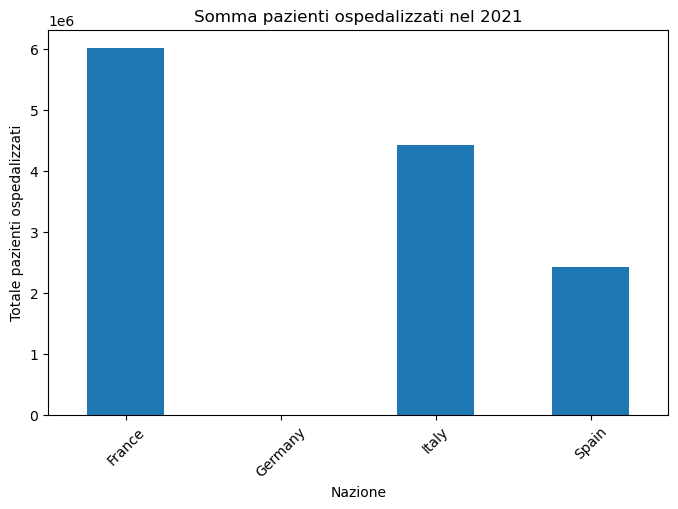

In [24]:
plt.figure(figsize=(8,5))
somma_ospedalizzati.plot(kind="bar")

plt.title("Somma pazienti ospedalizzati nel 2021")
plt.xlabel("Nazione")
plt.ylabel("Totale pazienti ospedalizzati")

plt.xticks(rotation=45)
plt.show()
